# Experiment 4 — Does sentiment *sign* beat a coin flip at calling the move?

Experiments 1–3: strong **same-day** correlation (FinBERT r ≈ +0.23), **zero** forward
correlation at every horizon. Here we ask the tradable version of the question:

**Hypothesis:** `sign(sentiment(t))` predicts `sign(forward return)` better than
(a) a **coin flip (50%)** and (b) the **majority-class** "always predict up" baseline
— and a simple sentiment-sign strategy beats **buy-and-hold**.

Two honest guards:
- TSLA drifted up, so "always up" already beats 50% — sentiment must beat *that*.
- The backtest uses only sentiment known by day *t*, held to *t+1* (no look-ahead).
  A same-day curve is shown but **labeled non-tradable**.

In [1]:
# 1. Setup
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "experiment_4" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
EXP2_CSV = REPO_ROOT / "experiment_2" / "tsla_daily_finbert.csv"
print("Repo root:", REPO_ROOT)

Repo root: /Users/georgia/Documents/Trading/sentimental_trading


## 2. Load FinBERT + VADER daily sentiment (experiment 2)

In [2]:
# 2. Sentiment
sent = pd.read_csv(EXP2_CSV, parse_dates=["date"])[["date", "finbert_sentiment", "vader_sentiment"]]
print(f"{len(sent)} sentiment days, {sent['date'].min().date()} -> {sent['date'].max().date()}")
sent.head()

565 sentiment days, 2024-01-02 -> 2026-04-08


,date,finbert_sentiment,vader_sentiment
0,2024-01-02,-0.223781,0.164387
1,2024-01-03,-0.015199,0.161350
2,2024-01-04,-0.153485,-0.007069
3,2024-01-05,-0.086602,0.084625
4,2024-01-08,-0.030544,0.086440


## 3. Fetch prices & build forward returns

In [3]:
# 3. Daily bars (SIP -> IEX fallback) + forward cumulative returns
import get_bars as gb
end = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

def fetch(feed):
    return list(gb.get_bars({"timeframe": "1Day", "start": "2024-01-01T00:00:00Z",
                             "end": end, "limit": 10000, "adjustment": "split",
                             "feed": feed, "sort": "asc"}))
try:
    bars = fetch("sip"); feed_used = "sip"
except Exception as e:
    print("SIP failed -> IEX"); bars = fetch("iex"); feed_used = "iex"

prices = pd.DataFrame(bars)
prices["date"] = pd.to_datetime(prices["t"], utc=True).dt.tz_localize(None).dt.normalize()
prices = prices.sort_values("date").reset_index(drop=True)

HORIZONS = [("+1d", 1), ("1 week (5d)", 5), ("2 weeks (10d)", 10), ("1 month (21d)", 21)]
for _, h in HORIZONS:
    prices[f"fwd_{h}"] = prices["c"].shift(-h) / prices["c"] - 1.0
prices["same_day"] = prices["c"].pct_change()
print(f"{len(prices)} bars via {feed_used}: {prices['date'].min().date()} -> {prices['date'].max().date()}")

SIP failed -> IEX


639 bars via iex: 2024-01-02 -> 2026-07-21


## 4. Merge sentiment with returns

In [4]:
# 4. Merge
df = prices.merge(sent, on="date", how="inner").sort_values("date").reset_index(drop=True)
print(f"{len(df)} rows with sentiment + forward returns")
df[["date", "c", "finbert_sentiment", "same_day", "fwd_5", "fwd_21"]].head()

565 rows with sentiment + forward returns


,date,c,finbert_sentiment,same_day,fwd_5,fwd_21
0,2024-01-02,248.48,-0.223781,NaN,-0.054733,-0.240140
1,2024-01-03,238.44,-0.015199,-0.040406,-0.019082,-0.212255
2,2024-01-04,237.94,-0.153485,-0.002097,-0.045011,-0.239094
3,2024-01-05,237.48,-0.086602,-0.001933,-0.078533,-0.220692
4,2024-01-08,240.42,-0.030544,0.012380,-0.085059,-0.219657


## 5. Directional hit-rate vs. two baselines

`hit_rate` = fraction of days where `sign(sentiment)` matches `sign(forward return)`.
Compared to a **coin flip (0.5)** and the **majority-class** accuracy
`max(P(up), P(down))`. Binomial p-value tests hit_rate ≠ 0.5.

In [5]:
# 5. Hit-rate table
def hit_stats(sent_col, ret):
    m = df[sent_col].notna() & df[ret].notna() & (df[sent_col] != 0) & (df[ret] != 0)
    s = np.sign(df.loc[m, sent_col]); r = np.sign(df.loc[m, ret])
    n = int(m.sum())
    hits = int((s == r).sum())
    hit_rate = hits / n
    p_up = float((r > 0).mean())
    majority = max(p_up, 1 - p_up)
    bt = stats.binomtest(hits, n, 0.5, alternative="two-sided")
    return {"n": n, "hit_rate": round(hit_rate, 4), "base_rate_up": round(p_up, 4),
            "majority_baseline": round(majority, 4),
            "edge_vs_coin": round(hit_rate - 0.5, 4),
            "edge_vs_majority": round(hit_rate - majority, 4),
            "binom_p_vs_50%": round(bt.pvalue, 4)}

rows = []
for model, col in [("FinBERT", "finbert_sentiment"), ("VADER", "vader_sentiment")]:
    for label, ret in [("same-day (0d)*", "same_day")] + [(l, f"fwd_{h}") for l, h in HORIZONS]:
        rows.append({"model": model, "horizon": label, **hit_stats(col, ret)})
hitrate = pd.DataFrame(rows)
hitrate.to_csv("tsla_hitrate.csv", index=False)
print("* same-day is contemporaneous (not tradable) — shown as reference\n")
hitrate

* same-day is contemporaneous (not tradable) — shown as reference



,model,horizon,n,hit_rate,base_rate_up,majority_baseline,edge_vs_coin,edge_vs_majority,binom_p_vs_50%
0,FinBERT,same-day (0d)*,564,0.5975,0.5035,0.5035,0.0975,0.0940,0.0000
1,FinBERT,+1d,565,0.4655,0.5009,0.5009,-0.0345,-0.0354,0.1098
2,FinBERT,1 week (5d),565,0.5097,0.4673,0.5327,0.0097,-0.0230,0.6740
3,FinBERT,2 weeks (10d),565,0.4903,0.5009,0.5009,-0.0097,-0.0106,0.6740
4,FinBERT,1 month (21d),565,0.4602,0.5204,0.5204,-0.0398,-0.0602,0.0641
5,VADER,same-day (0d)*,563,0.5311,0.5027,0.5027,0.0311,0.0284,0.1518
6,VADER,+1d,564,0.5106,0.5000,0.5000,0.0106,0.0106,0.6433
7,VADER,1 week (5d),564,0.4734,0.4663,0.5337,-0.0266,-0.0603,0.2220
8,VADER,2 weeks (10d),564,0.4663,0.5018,0.5018,-0.0337,-0.0355,0.1192
9,VADER,1 month (21d),564,0.4787,0.5213,0.5213,-0.0213,-0.0426,0.3328


## 6. Conditional accuracy (FinBERT, same-day & next-day)
When sentiment is positive, how often does price actually go up — and vice versa?

In [6]:
# 6. Directional confusion for FinBERT
def conditional(ret, title):
    m = df["finbert_sentiment"].notna() & df[ret].notna() & (df["finbert_sentiment"] != 0) & (df[ret] != 0)
    s = np.sign(df.loc[m, "finbert_sentiment"]); r = np.sign(df.loc[m, ret])
    pos, neg = s > 0, s < 0
    print(f"{title}  (n={int(m.sum())})")
    print(f"   sentiment > 0 -> P(price up)   = {(r[pos] > 0).mean():.3f}  (n={int(pos.sum())})")
    print(f"   sentiment < 0 -> P(price down) = {(r[neg] < 0).mean():.3f}  (n={int(neg.sum())})")
    print()

conditional("same_day", "SAME-DAY (contemporaneous, not tradable)")
conditional("fwd_1", "NEXT-DAY (tradable)")
conditional("fwd_5", "1 WEEK forward")

SAME-DAY (contemporaneous, not tradable)  (n=564)
   sentiment > 0 -> P(price up)   = 0.621  (n=235)
   sentiment < 0 -> P(price down) = 0.581  (n=329)

NEXT-DAY (tradable)  (n=565)
   sentiment > 0 -> P(price up)   = 0.460  (n=235)
   sentiment < 0 -> P(price down) = 0.470  (n=330)

1 WEEK forward  (n=565)
   sentiment > 0 -> P(price up)   = 0.472  (n=235)
   sentiment < 0 -> P(price down) = 0.536  (n=330)



## 7. Simple backtest — sentiment sign, held one day

Decide at close of day *t* using sentiment through *t*; hold to close *t+1*.
Position = +1 (long) if sentiment>0, −1 (short) if <0. No costs. Compared to
buy-and-hold. The **same-day** curve uses `sign(sentiment(t))·return(t)` — this
**peeks at the same day's move and is NOT tradable**, shown only to size the signal.

In [7]:
# 7. Backtest
bt = df.dropna(subset=["fwd_1", "finbert_sentiment"]).copy()
pos = np.sign(bt["finbert_sentiment"])
strat_ret = pos * bt["fwd_1"]                    # tradable: decide at t, earn t->t+1
bh_ret = bt["fwd_1"]                             # buy and hold (next-day return)
lookahead_ret = np.sign(bt["finbert_sentiment"]) * bt["same_day"]  # NOT tradable

def summ(r, name):
    r = r.dropna()
    total = float((1 + r).prod() - 1)
    ann = (1 + r.mean()) ** 252 - 1
    sharpe = float(r.mean() / r.std() * np.sqrt(252)) if r.std() > 0 else float("nan")
    hit = float((np.sign(r) > 0).mean())
    return {"strategy": name, "total_return": round(total, 3),
            "ann_return": round(ann, 3), "sharpe": round(sharpe, 2),
            "daily_hit": round(hit, 3)}

perf = pd.DataFrame([
    summ(strat_ret, "Sentiment sign L/S (tradable, t->t+1)"),
    summ(bh_ret, "Buy & hold"),
    summ(lookahead_ret, "Same-day sign (LOOK-AHEAD, not tradable)"),
])
perf

,strategy,total_return,ann_return,sharpe,daily_hit
0,"Sentiment sign L/S (tradable, t->t+1)",-0.836,-0.459,-1.00,0.465
1,Buy & hold,0.402,0.398,0.55,0.501
2,"Same-day sign (LOOK-AHEAD, not tradable)",93.317,8.047,3.70,0.598


## 8. Plots

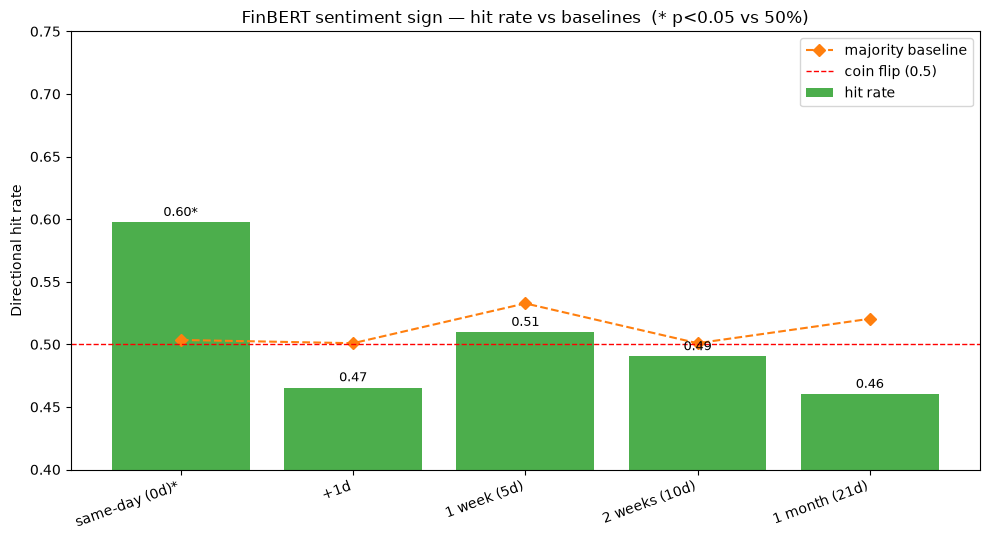

In [8]:
# 8a. Hit-rate vs horizon (FinBERT) with baselines
fb = hitrate[hitrate["model"] == "FinBERT"]
x = range(len(fb))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x, fb["hit_rate"], color="tab:green", alpha=0.85, label="hit rate")
ax.plot(x, fb["majority_baseline"], "D--", color="tab:orange", label="majority baseline")
ax.axhline(0.5, color="red", ls="--", lw=1, label="coin flip (0.5)")
for i, (_, row) in enumerate(fb.iterrows()):
    mark = "*" if row["binom_p_vs_50%"] < 0.05 else ""
    ax.text(i, row["hit_rate"] + 0.005, f"{row['hit_rate']:.2f}{mark}", ha="center", fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(fb["horizon"], rotation=20, ha="right")
ax.set_ylim(0.4, max(0.75, fb["hit_rate"].max() + 0.05))
ax.set_ylabel("Directional hit rate"); ax.set_title("FinBERT sentiment sign — hit rate vs baselines  (* p<0.05 vs 50%)")
ax.legend(); plt.tight_layout(); plt.show()

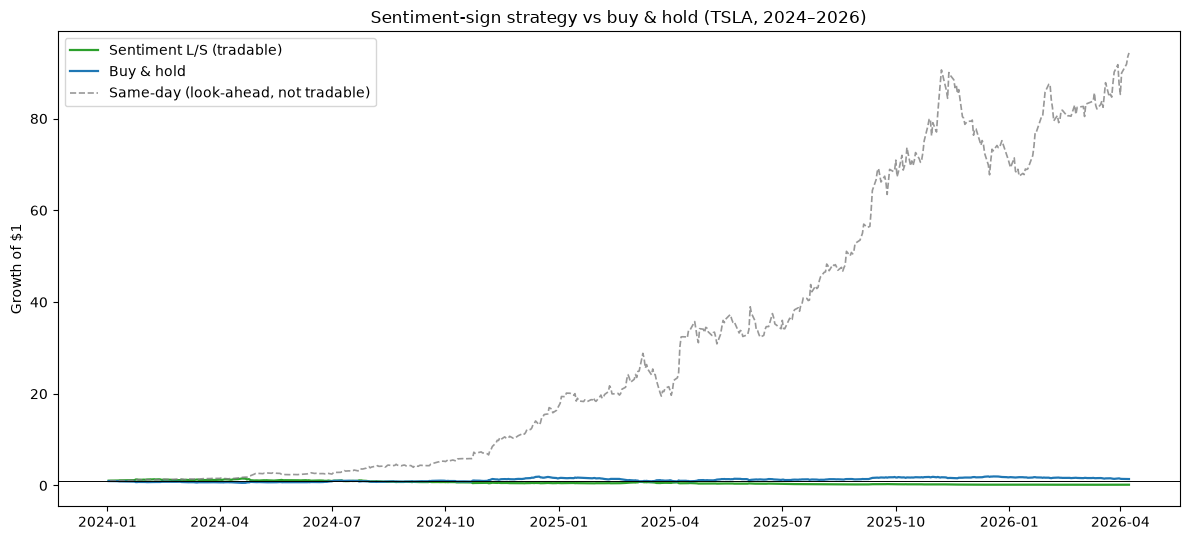

In [9]:
# 8b. Backtest equity curves
eq_strat = (1 + strat_ret).cumprod()
eq_bh = (1 + bh_ret).cumprod()
eq_look = (1 + lookahead_ret).cumprod()
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(bt["date"], eq_strat, color="tab:green", lw=1.6, label="Sentiment L/S (tradable)")
ax.plot(bt["date"], eq_bh, color="tab:blue", lw=1.6, label="Buy & hold")
ax.plot(bt["date"], eq_look, color="tab:gray", lw=1.2, ls="--", alpha=0.8, label="Same-day (look-ahead, not tradable)")
ax.axhline(1, color="black", lw=0.7)
ax.set_ylabel(r"Growth of \$1"); ax.set_title("Sentiment-sign strategy vs buy & hold (TSLA, 2024–2026)")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Verdict

In [10]:
# 9. Verdict
print("HYPOTHESIS: sign(sentiment(t)) beats coin flip / majority / buy&hold\n" + "=" * 74)

nd = hitrate[(hitrate["model"] == "FinBERT") & (hitrate["horizon"] == "+1d")].iloc[0]
print("Tradable next-day (FinBERT):")
print(f"   hit rate        = {nd['hit_rate']:.3f}   (coin flip 0.500, p={nd['binom_p_vs_50%']})")
print(f"   majority basel. = {nd['majority_baseline']:.3f}   edge vs majority = {nd['edge_vs_majority']:+.3f}")

beats_coin = nd["hit_rate"] > 0.5 and nd["binom_p_vs_50%"] < 0.05
beats_major = nd["edge_vs_majority"] > 0
strat = perf.iloc[0]; bh = perf.iloc[1]
beats_bh = strat["total_return"] > bh["total_return"]

print(f"\nBacktest (tradable): total {strat['total_return']:+.1%} vs buy&hold {bh['total_return']:+.1%}"
      f" | Sharpe {strat['sharpe']} vs {bh['sharpe']}")
print("\nDirectional test:")
print(f"   beats coin flip (sig)? {'YES' if beats_coin else 'NO'}")
print(f"   beats majority base?   {'YES' if beats_major else 'NO'}")
print(f"   beats buy & hold?      {'YES' if beats_bh else 'NO'}")

sd = hitrate[(hitrate["model"] == "FinBERT") & (hitrate["horizon"] == "same-day (0d)*")].iloc[0]
print(f"\nReference — same-day hit rate (not tradable): {sd['hit_rate']:.3f} (p={sd['binom_p_vs_50%']})")

verdict = ("SUPPORTED" if (beats_coin and beats_major and beats_bh)
           else "NOT SUPPORTED — no tradable directional edge")
print("\n" + "=" * 74 + f"\nVERDICT: {verdict}")
print("Saved -> tsla_hitrate.csv")

HYPOTHESIS: sign(sentiment(t)) beats coin flip / majority / buy&hold
Tradable next-day (FinBERT):
   hit rate        = 0.466   (coin flip 0.500, p=0.1098)
   majority basel. = 0.501   edge vs majority = -0.035

Backtest (tradable): total -83.6% vs buy&hold +40.2% | Sharpe -1.0 vs 0.55

Directional test:
   beats coin flip (sig)? NO
   beats majority base?   NO
   beats buy & hold?      NO

Reference — same-day hit rate (not tradable): 0.598 (p=0.0)

VERDICT: NOT SUPPORTED — no tradable directional edge
Saved -> tsla_hitrate.csv


### Reading this

- A **same-day** hit rate well above 50% just confirms the contemporaneous reaction
  — it is not tradable (you can't act before the move you're measuring).
- The honest test is **next-day (t+1)**: hit rate near 0.5, no significance, and no edge
  over "always up" would mean sentiment sign carries no forward directional information.
- If the **tradable equity curve** tracks or trails buy-and-hold, sentiment sign adds
  no economic value — consistent with the zero forward correlation from experiment 3.